# Chapter 3 (hadronic) — Notebook 3: Mass distribution with backgrounds and data

**Goals**

- Build the m(jjb) distribution for signal, backgrounds and real data (stacked + overlay).
- Decide on the fit window for Notebook 4.

In [1]:
%matplotlib inline
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from topmass import io, kinematics, selection, plotting, fitting, neutrino, pairing, weights, style
from topmass.constants import M_W, M_TOP

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████████████████████████| 374/374 [00:00<00:00, 1375.31datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


(<Figure size 770x550 with 2 Axes>,
 (<Axes: xlabel='mjjb', ylabel='Events'>,
  <Axes: xlabel='$m(jjb)$ [GeV]', ylabel='Data / MC'>))

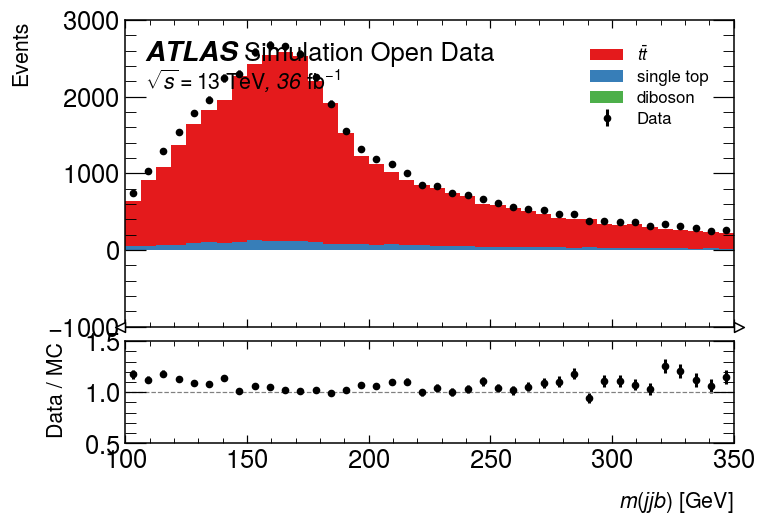

In [2]:
io.setup()
samples = io.build_samples()
cuts = selection.SemilepCuts(n_jets_min=4, n_bjets_min=2)

def mjjb(ev):
    lep = kinematics.leading_lepton(ev)
    jets = kinematics.jet_vectors(ev)
    is_b = ev.jet_btag_quantile >= cuts.btag_quantile_min
    b_jets, light = jets[is_b], jets[~is_b]
    keep = (ak.num(b_jets) >= 2) & (ak.num(light) >= 2)
    lep, b_jets, light = lep[keep], b_jets[keep][:, :2], light[keep]
    _, b_had = pairing.assign_bjets(b_jets, lep)
    j1, j2, _ = pairing.best_W_pair(light)
    return (j1 + j2 + b_had).mass, keep

hists = {}
for p in ['ttbar', 'single_top', 'diboson', 'data']:
    ev = io.load_process(p, samples, fraction=0.1)
    sel = selection.semilep_preselection(ev, cuts)
    ev = ev[sel]
    if len(ev) == 0:
        continue
    m, keep = mjjb(ev)
    w = weights.weight_for(p, ev)[keep]
    hists[p] = plotting.make_hist(m, bins=40, range=(100, 350), weight=w, name='mjjb')

plotting.stacked_plot(hists, xlabel='$m(jjb)$ [GeV]')

## ✏️ Your turn 3.1

▶️ Change the mass window and re-run.

Using the stacked histograms from above, this computes the signal **purity** $S / (S + B)$ (weighted)
inside the window `WIN_LO < m(jjb) < WIN_HI`. A good fit window should be signal-rich — is the
purity high enough around the top mass?

> **Stretch (optional):** widen or shift the window and watch the purity drop as you let in
> background-dominated sidebands.

In [3]:
WIN_LO, WIN_HI = 150, 200    # ✏️ try (160, 190) or (120, 250)

centres = hists['ttbar'].axes[0].centers
in_win = (centres >= WIN_LO) & (centres < WIN_HI)
sig = float(hists['ttbar'].values()[in_win].sum())
bkg = float(sum(hists[p].values()[in_win].sum() for p in ('single_top', 'diboson') if p in hists))
print(f'window [{WIN_LO}, {WIN_HI}] GeV:  S = {sig:.1f},  B = {bkg:.1f},  purity S/(S+B) = {sig / (sig + bkg):.2f}')

window [150, 200] GeV:  S = 16123.1,  B = 829.8,  purity S/(S+B) = 0.95
